[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aubreycoffey/single-cell-analysis-pipeline/blob/main/notebooks/02_clustering_annotation.ipynb)

# Notebook 2: Clustering & Cell Type Annotation

Starting from the preprocessed AnnData object, this notebook covers:
- PCA
- Neighborhood graph construction
- UMAP embedding
- Leiden clustering
- Cell type annotation using canonical marker genes

## Google Drive setup

Mount Drive to persist data between notebook sessions. All `.h5ad` files will be saved to `MyDrive/scrnaseq-pbmc-pipeline-data/`.

In [6]:
from google.colab import drive
drive.mount('/content/drive')
import os
DATA_DIR = '/content/drive/MyDrive/scrnaseq-pbmc-pipeline-data'
os.makedirs(DATA_DIR, exist_ok=True)
print(f'Data directory: {DATA_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data directory: /content/drive/MyDrive/scrnaseq-pbmc-pipeline-data


In [7]:
import sys
!{sys.executable} -m pip install -q scanpy leidenalg python-igraph

In [8]:
import scanpy as sc
import matplotlib.pyplot as plt

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, facecolor='white')

/tmp/ipykernel_32243/233994681.py:5: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=100, facecolor='white')


In [9]:
adata = sc.read_h5ad(f'{DATA_DIR}/pbmc_preprocessed.h5ad')
print(adata)

AnnData object with n_obs × n_vars = 2638 × 1830
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p'
    layers: 'counts'


## 1. PCA

Principal component analysis reduces the ~2000 HVG dimensions to 50 PCs. We inspect the elbow plot to confirm the number of PCs captures most variance.

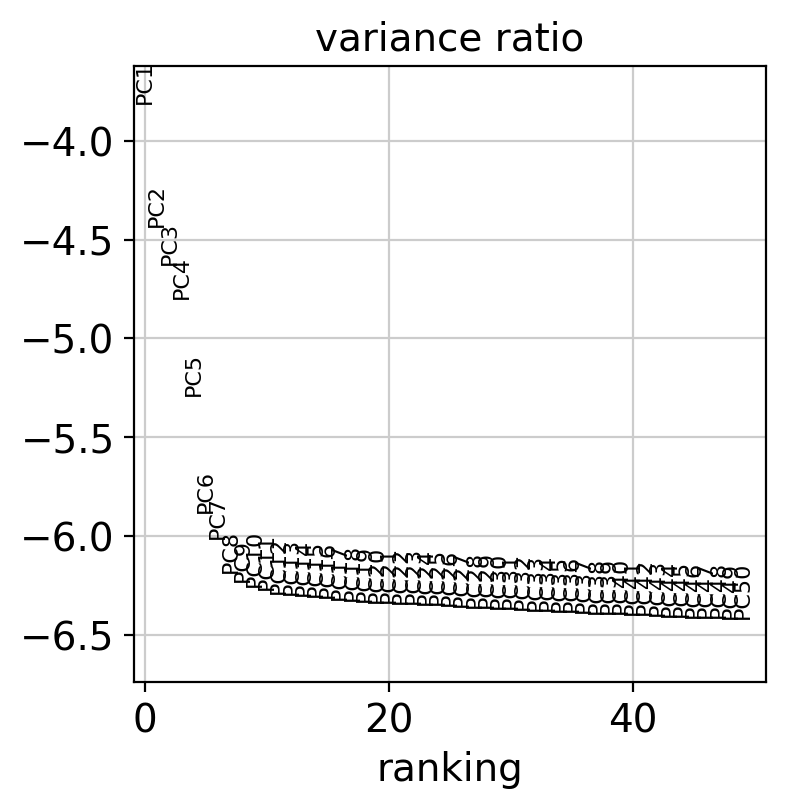

In [10]:
sc.tl.pca(adata, svd_solver='arpack', n_comps=50)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

## 2. Neighborhood graph

We compute a k-nearest neighbor graph in PCA space (using the top 40 PCs). This graph is the foundation for both UMAP and Leiden clustering.

In [18]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
print('Neighborhood graph computed.')

Neighborhood graph computed.


## 3. UMAP

Uniform Manifold Approximation and Projection (UMAP) embeds the neighborhood graph in 2D for visualization.

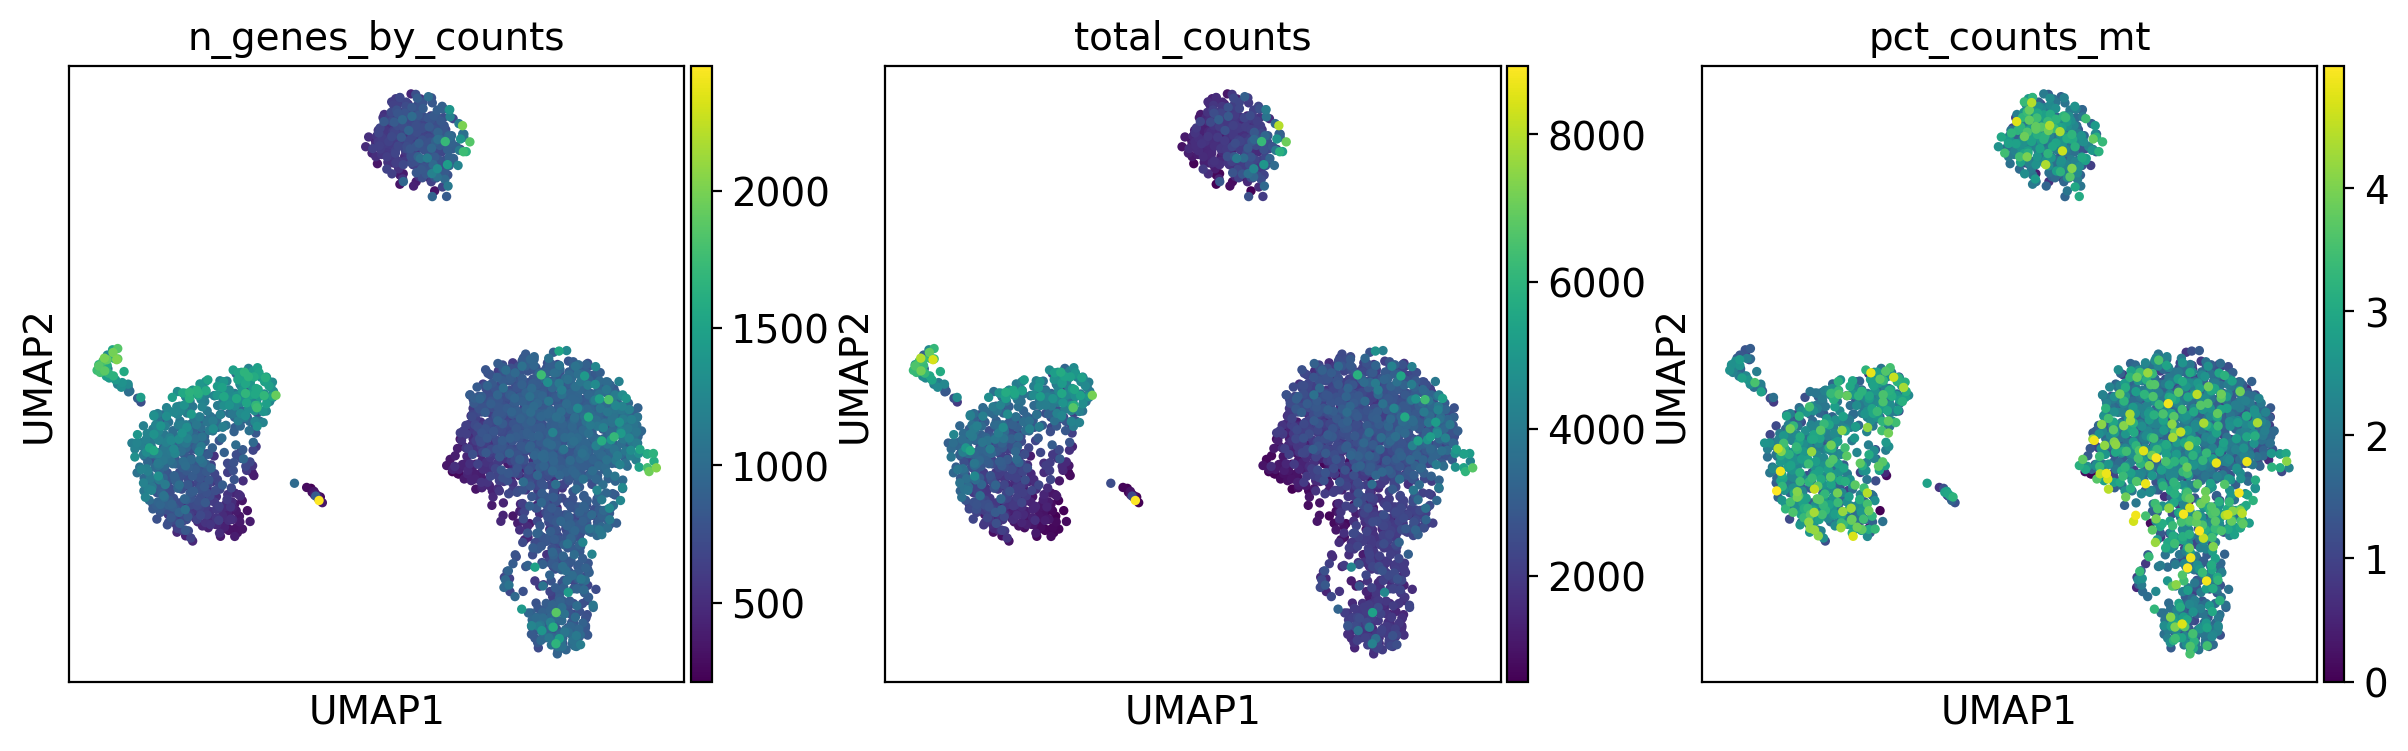

In [19]:
sc.tl.umap(adata)
sc.pl.umap(adata, color=['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], ncols=3)

## 4. Leiden clustering

The Leiden algorithm partitions the neighborhood graph into clusters. `resolution` controls granularity — higher values produce more clusters.

/tmp/ipykernel_32243/2337390110.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=0.5)


Clusters found: 6


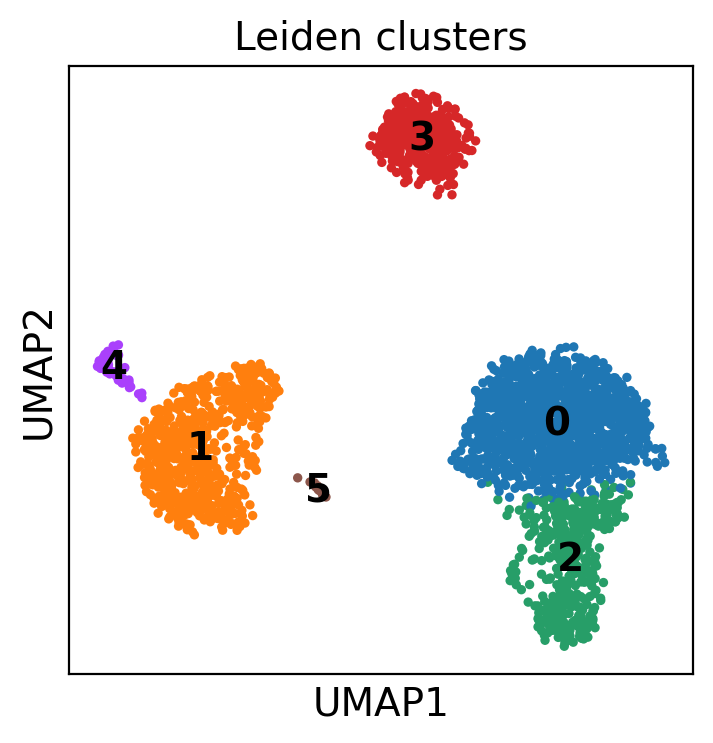

In [13]:
sc.tl.leiden(adata, resolution=0.5)
print(f'Clusters found: {adata.obs.leiden.nunique()}')
sc.pl.umap(adata, color='leiden', legend_loc='on data', title='Leiden clusters')

## 5. Cell type annotation

We use canonical PBMC marker genes to annotate each cluster:

| Marker | Cell type |
|---|---|
| IL7R, CCR7 | Naive CD4+ T |
| IL7R, S100A4 | Memory CD4+ T |
| CD14, LYZ | CD14+ Monocytes |
| MS4A1 | B cells |
| CD8A | CD8+ T cells |
| FCGR3A, MS4A7 | FCGR3A+ Monocytes |
| GNLY, NKG7 | NK cells |
| FCER1A, CST3 | Dendritic cells |
| PPBP | Megakaryocytes |

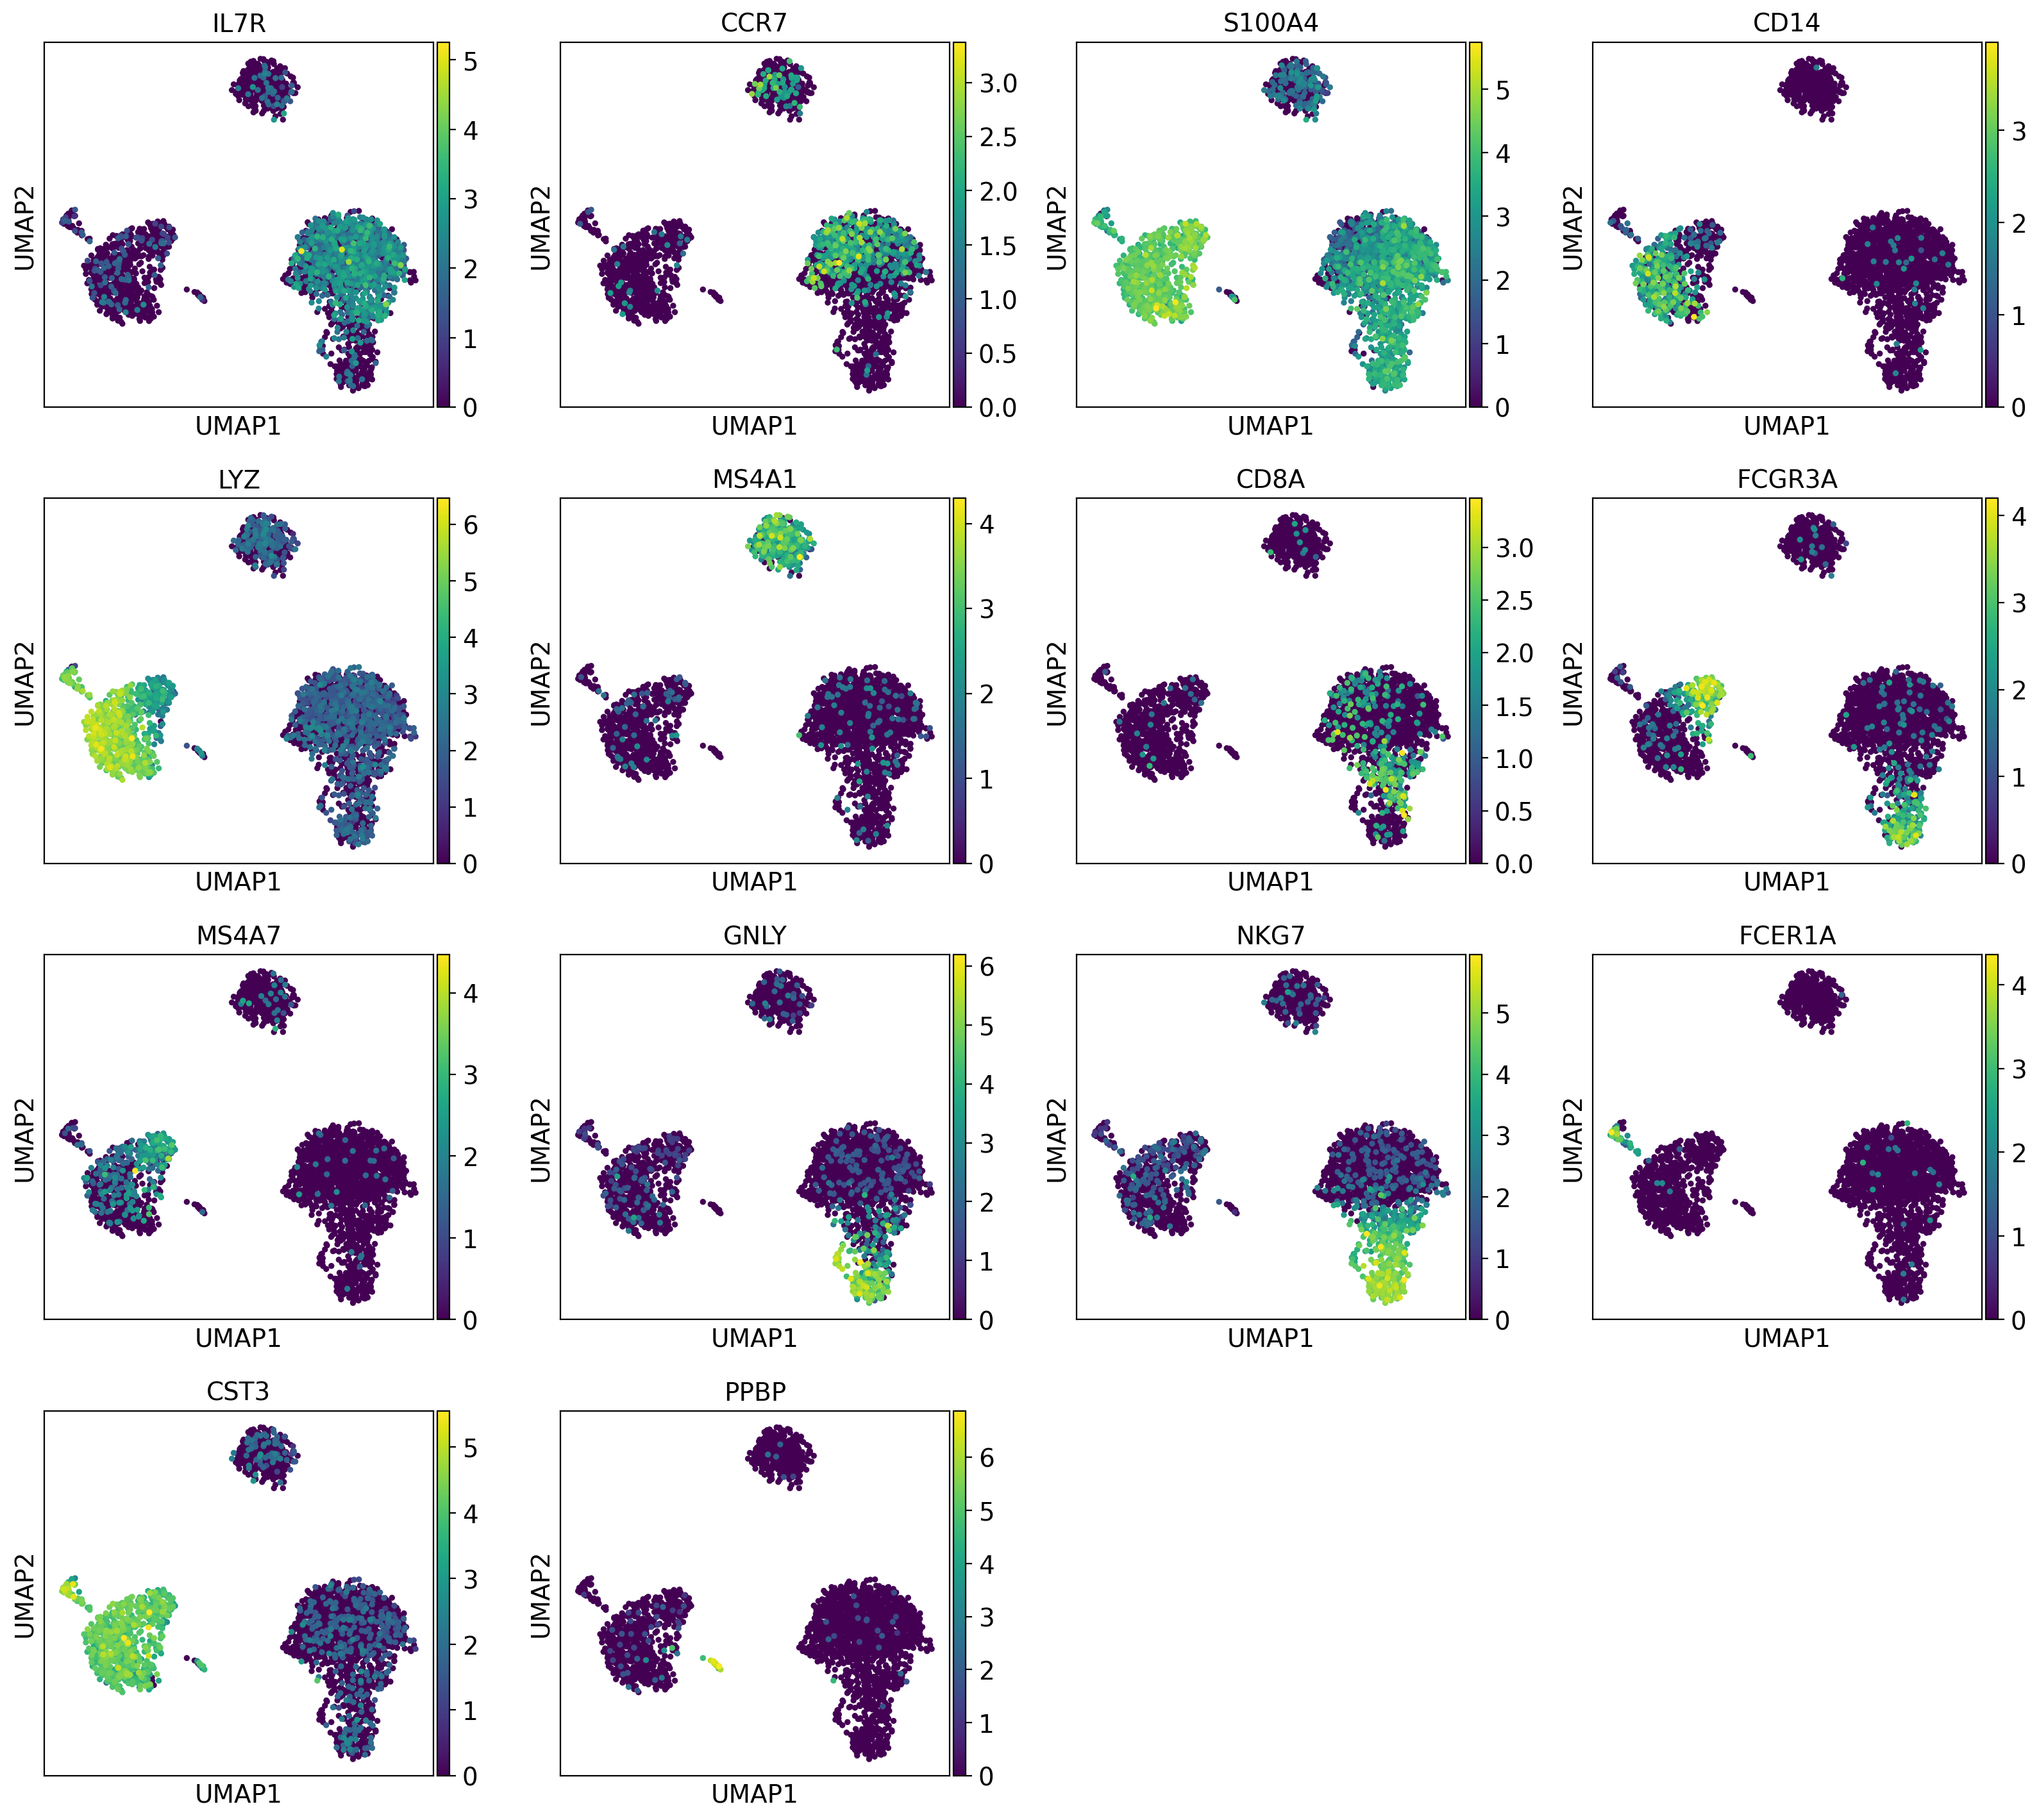

In [14]:
marker_genes = ['IL7R', 'CCR7', 'S100A4', 'CD14', 'LYZ',
               'MS4A1', 'CD8A', 'FCGR3A', 'MS4A7',
               'GNLY', 'NKG7', 'FCER1A', 'CST3', 'PPBP']

sc.pl.umap(adata, color=marker_genes, ncols=4)

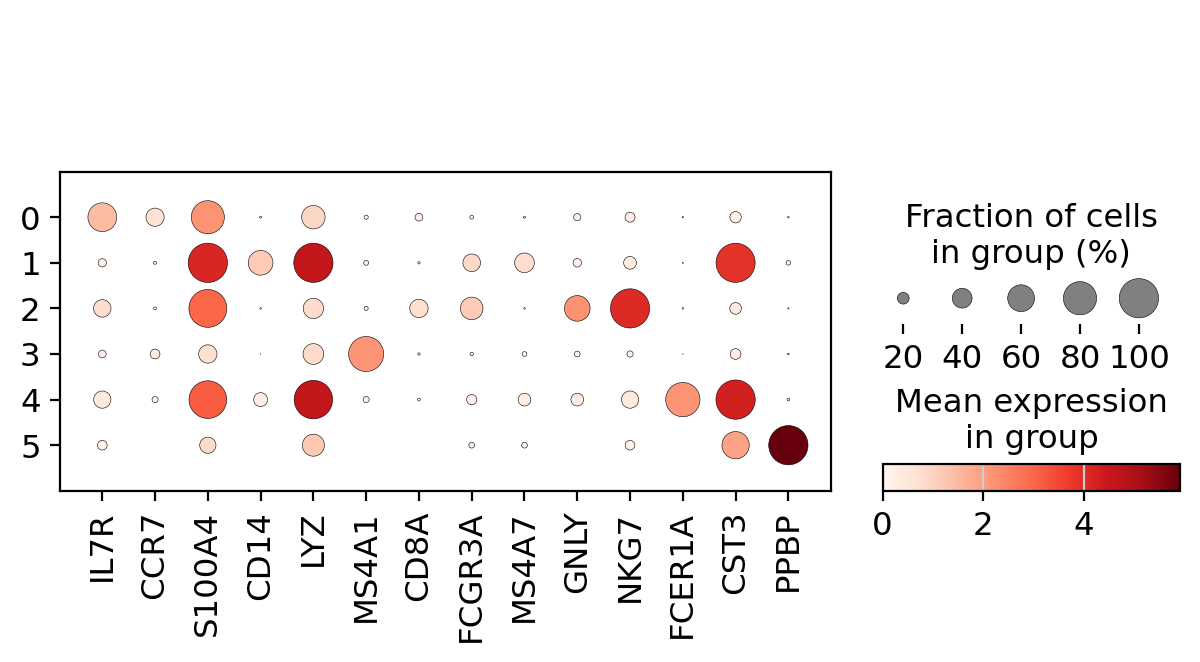

In [15]:
sc.pl.dotplot(adata, marker_genes, groupby='leiden')

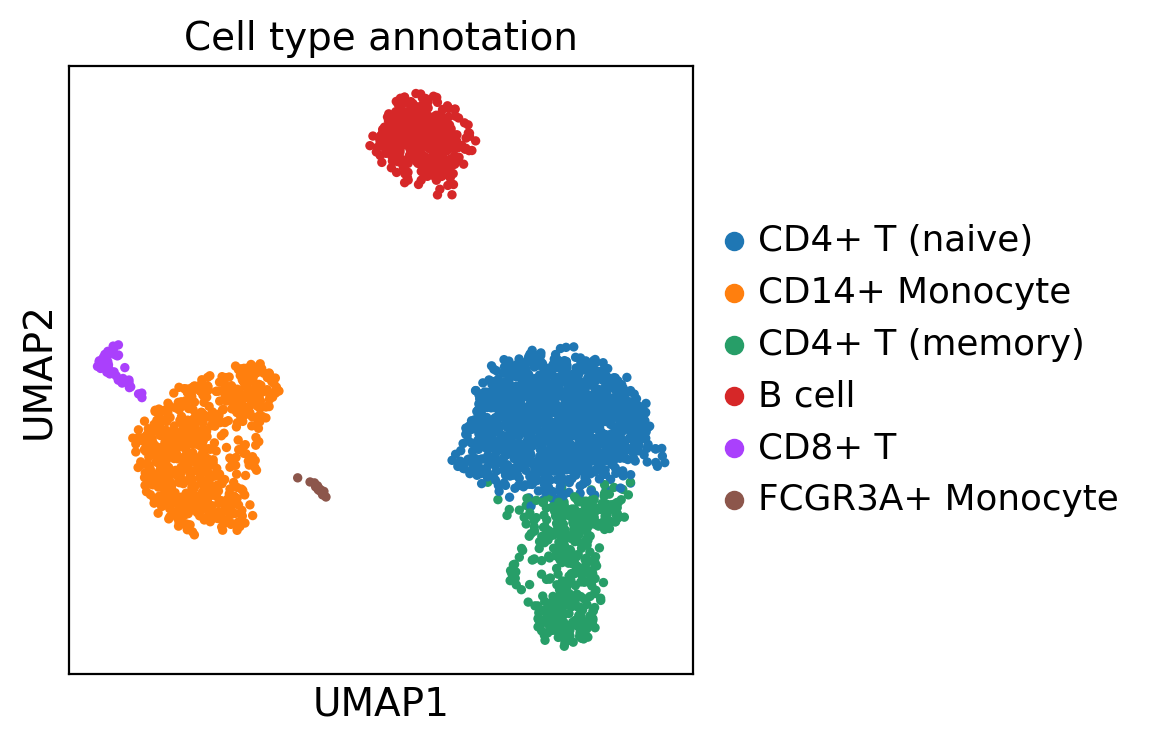

In [16]:
# Manual annotation based on marker expression
cell_type_map = {
    '0': 'CD4+ T (naive)',
    '1': 'CD14+ Monocyte',
    '2': 'CD4+ T (memory)',
    '3': 'B cell',
    '4': 'CD8+ T',
    '5': 'FCGR3A+ Monocyte',
    '6': 'NK cell',
    '7': 'Dendritic cell',
    '8': 'Megakaryocyte'
}

adata.obs['cell_type'] = adata.obs['leiden'].map(cell_type_map)
sc.pl.umap(adata, color='cell_type', legend_loc='right margin', title='Cell type annotation')

## 6. Save

In [17]:
adata.write(f'{DATA_DIR}/pbmc_clustered.h5ad')
print('Saved to ../data/pbmc_clustered.h5ad')

Saved to ../data/pbmc_clustered.h5ad
